In [2]:
import numpy as np
import pandas as pd
from collections import Counter
from scipy.optimize import minimize
from scipy.special import logsumexp

# ============================================================
# USTAWIENIA
# ============================================================

CSV_PATH = "experiment_data_fig2d.csv"   # <- tu wpisz swój plik
DELIMITER = ","

# "auto"             -> jeśli wierszy mniej niż kolumn, zakładam atoms x shots i transponuję
# "atoms_by_shots"   -> dane są w układzie atoms x shots
# "shots_by_atoms"   -> dane są w układzie shots x atoms
ORIENTATION = "auto"

# jeśli None, liczba wierzchołków = liczba kolumn po ustawieniu orientacji
N_VERTICES = None

# jeśli True, to po wykryciu strzałów spoza nośnika ścieżki analizuję tylko poprawne strzały
# jeśli False, to kończę z informacją, że exact mult_G(1,y) odpada
USE_ONLY_VALID_SHOTS = True

# liczba bootstrapów do testu dopasowania
N_BOOT = 300
RANDOM_SEED = 123

# zapisywanie tabeli ze stanami
SAVE_STATE_TABLE = True
STATE_TABLE_PATH = "state_counts_path_multG_test.csv"


# ============================================================
# POMOCNICZE
# ============================================================

def load_binary_data(csv_path, delimiter=",", orientation="auto"):
    arr = np.loadtxt(csv_path, delimiter=delimiter)

    # jeśli plik jest 1D
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    # zamiana na 0/1
    uniq = np.unique(arr)
    if not np.all(np.isin(uniq, [0, 1])):
        # awaryjnie progowanie
        arr = (arr > 0.5).astype(int)
    else:
        arr = arr.astype(int)

    original_shape = arr.shape

    if orientation == "atoms_by_shots":
        X = arr.T
    elif orientation == "shots_by_atoms":
        X = arr
    elif orientation == "auto":
        if arr.shape[0] <= arr.shape[1]:
            X = arr.T
        else:
            X = arr
    else:
        raise ValueError("Nieznana opcja ORIENTATION.")

    return X, original_shape


def path_edges(d):
    return [(i, i + 1) for i in range(d - 1)]


def is_independent_set_on_path(x):
    x = np.asarray(x, dtype=int)
    return np.all(x[:-1] + x[1:] <= 1)


def valid_mask_on_path(X):
    return np.array([is_independent_set_on_path(row) for row in X], dtype=bool)


def enumerate_independent_sets_path(d):
    states = []
    for mask in range(1 << d):
        bits = tuple((mask >> i) & 1 for i in range(d))
        if all(bits[i] + bits[i + 1] <= 1 for i in range(d - 1)):
            states.append(bits)
    return states


def state_to_string(state):
    return "".join(str(int(v)) for v in state)


def count_states(X):
    counter = Counter(map(tuple, X.astype(int)))
    return counter


def observed_counts_in_state_order(X, states):
    counter = count_states(X)
    return np.array([counter.get(tuple(s), 0) for s in states], dtype=int)


def fit_multG1_path_mle(X, states, eta_start=None):
    """
    Model:
        P(X = n) = exp(<eta, n>) / Z(eta),  n w zbiorze niezależnych zbiorów ścieżki
    gdzie eta_i = log y_i.
    """
    X = np.asarray(X, dtype=int)
    M, d = X.shape
    S = np.asarray(states, dtype=float)   # (#states, d)
    T = X.sum(axis=0).astype(float)       # statystyka dostateczna

    if eta_start is None:
        eta_start = np.zeros(d, dtype=float)

    def obj(eta):
        a = S @ eta
        return M * logsumexp(a) - T @ eta

    def grad(eta):
        a = S @ eta
        lse = logsumexp(a)
        p = np.exp(a - lse)
        mean_state = p @ S
        return M * mean_state - T

    res = minimize(
        fun=obj,
        x0=eta_start,
        jac=grad,
        method="L-BFGS-B"
    )

    if not res.success:
        raise RuntimeError(f"MLE nie zbiega: {res.message}")

    eta_hat = res.x
    logw = S @ eta_hat
    logZ = logsumexp(logw)
    p_hat = np.exp(logw - logZ)
    y_hat = np.exp(eta_hat)

    return {
        "eta_hat": eta_hat,
        "y_hat": y_hat,
        "p_hat": p_hat,
        "logZ": logZ,
        "opt_result": res
    }


def g_statistic(observed, expected):
    observed = np.asarray(observed, dtype=float)
    expected = np.asarray(expected, dtype=float)

    mask = observed > 0
    return 2.0 * np.sum(observed[mask] * np.log(observed[mask] / expected[mask]))


def parametric_bootstrap_gof(X, states, p_hat, eta_hat, n_boot=300, seed=123):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=int)
    M = X.shape[0]
    S = np.asarray(states, dtype=int)

    obs_counts = observed_counts_in_state_order(X, states)
    exp_counts = M * p_hat
    G_obs = g_statistic(obs_counts, exp_counts)

    boot_stats = []

    for _ in range(n_boot):
        idx = rng.choice(len(states), size=M, replace=True, p=p_hat)
        Xb = S[idx, :]

        fit_b = fit_multG1_path_mle(Xb, states, eta_start=eta_hat)
        p_b = fit_b["p_hat"]

        obs_b = observed_counts_in_state_order(Xb, states)
        exp_b = M * p_b
        G_b = g_statistic(obs_b, exp_b)
        boot_stats.append(G_b)

    boot_stats = np.asarray(boot_stats, dtype=float)
    p_value = (1 + np.sum(boot_stats >= G_obs)) / (n_boot + 1)

    return {
        "G_obs": G_obs,
        "boot_stats": boot_stats,
        "p_value": p_value
    }


# ============================================================
# GŁÓWNA ANALIZA
# ============================================================

X_raw, original_shape = load_binary_data(
    CSV_PATH,
    delimiter=DELIMITER,
    orientation=ORIENTATION
)

if N_VERTICES is None:
    d = X_raw.shape[1]
else:
    d = N_VERTICES
    if X_raw.shape[1] != d:
        raise ValueError(
            f"Po ustawieniu orientacji dane mają {X_raw.shape[1]} kolumn, a N_VERTICES={d}."
        )

M_total = X_raw.shape[0]
edges = path_edges(d)

print("=== PODSTAWOWE INFO ===")
print(f"Oryginalny kształt pliku: {original_shape}")
print(f"Kształt po ustawieniu orientacji (shots x atoms): {X_raw.shape}")
print(f"Liczba wierzchołków ścieżki: {d}")
print(f"Krawędzie ścieżki: {edges}")
print()

mask_valid = valid_mask_on_path(X_raw)
n_valid = int(mask_valid.sum())
n_invalid = int((~mask_valid).sum())

print("=== NOŚNIK MODELU mult_G(1,y) DLA ŚCIEŻKI ===")
print(f"Liczba wszystkich strzałów: {M_total}")
print(f"Liczba strzałów poprawnych (niezależne zbiory): {n_valid}")
print(f"Liczba strzałów niepoprawnych: {n_invalid}")
print(f"Udział niepoprawnych: {n_invalid / M_total:.6f}")
print()

if n_invalid > 0 and not USE_ONLY_VALID_SHOTS:
    raise RuntimeError(
        "Są strzały spoza nośnika ścieżki, więc exact mult_G(1,y) odpada. "
        "Ustaw USE_ONLY_VALID_SHOTS=True, jeśli chcesz dopasować model tylko do poprawnych strzałów."
    )

X = X_raw[mask_valid].copy()
M = X.shape[0]

states = enumerate_independent_sets_path(d)
state_strings = [state_to_string(s) for s in states]

print("=== STANY W NOŚNIKU ===")
print(f"Liczba wszystkich stanów dopuszczalnych dla ścieżki: {len(states)}")
print("Stany:", state_strings)
print()

obs_counts = observed_counts_in_state_order(X, states)
emp_probs = obs_counts / M

fit = fit_multG1_path_mle(X, states)
eta_hat = fit["eta_hat"]
y_hat = fit["y_hat"]
p_hat = fit["p_hat"]

exp_counts = M * p_hat
G = g_statistic(obs_counts, exp_counts)

state_df = pd.DataFrame({
    "state": state_strings,
    "observed_count": obs_counts,
    "observed_prob": emp_probs,
    "expected_prob_hat": p_hat,
    "expected_count_hat": exp_counts,
    "num_excited": [sum(s) for s in states]
}).sort_values(["observed_count", "state"], ascending=[False, True]).reset_index(drop=True)

print("=== ESTYMACJA PARAMETRÓW ===")
for i, val in enumerate(y_hat):
    print(f"y_{i+1} = {val:.6f}")
print()

print("=== TABELA STANÓW ===")
print(state_df.to_string(index=False))
print()

if SAVE_STATE_TABLE:
    state_df.to_csv(STATE_TABLE_PATH, index=False)
    print(f"Zapisano tabelę stanów do: {STATE_TABLE_PATH}")
    print()

print("=== TEST DOPASOWANIA: bootstrap parametryczny na statystyce G ===")
boot = parametric_bootstrap_gof(
    X=X,
    states=states,
    p_hat=p_hat,
    eta_hat=eta_hat,
    n_boot=N_BOOT,
    seed=RANDOM_SEED
)

print(f"G_obs = {boot['G_obs']:.6f}")
print(f"bootstrap p-value = {boot['p_value']:.6f}")
print()

print("=== INTERPRETACJA ROBOCZA ===")
if n_invalid > 0:
    print("UWAGA: były strzały spoza nośnika ścieżki.")
    print("To już samo w sobie obala exact mult_G(1,y) dla całych danych.")
    if USE_ONLY_VALID_SHOTS:
        print("Test dopasowania powyżej dotyczy tylko strzałów poprawnych.")
else:
    print("Wszystkie strzały leżą w nośniku ścieżki.")
    if boot["p_value"] < 0.05:
        print("Na poziomie 0.05 są przesłanki przeciw dopasowaniu mult_G(1,y).")
    else:
        print("Na poziomie 0.05 nie ma podstaw do odrzucenia mult_G(1,y).")

print()
print("=== DODATKOWO: ROZKŁAD LICZBY WZBUDZEŃ ===")
excited_obs = X.sum(axis=1)
excited_df = (
    pd.Series(excited_obs)
    .value_counts()
    .sort_index()
    .rename_axis("num_excited")
    .reset_index(name="count")
)
excited_df["prob"] = excited_df["count"] / len(excited_obs)
print(excited_df.to_string(index=False))

=== PODSTAWOWE INFO ===
Oryginalny kształt pliku: (4, 678)
Kształt po ustawieniu orientacji (shots x atoms): (678, 4)
Liczba wierzchołków ścieżki: 4
Krawędzie ścieżki: [(0, 1), (1, 2), (2, 3)]

=== NOŚNIK MODELU mult_G(1,y) DLA ŚCIEŻKI ===
Liczba wszystkich strzałów: 678
Liczba strzałów poprawnych (niezależne zbiory): 191
Liczba strzałów niepoprawnych: 487
Udział niepoprawnych: 0.718289

=== STANY W NOŚNIKU ===
Liczba wszystkich stanów dopuszczalnych dla ścieżki: 8
Stany: ['0000', '1000', '0100', '0010', '1010', '0001', '1001', '0101']

=== ESTYMACJA PARAMETRÓW ===
y_1 = 3.111098
y_2 = 11.341018
y_3 = 14.009559
y_4 = 3.954570

=== TABELA STANÓW ===
state  observed_count  observed_prob  expected_prob_hat  expected_count_hat  num_excited
 0101              63       0.329843           0.334311           63.853309            2
 1010              61       0.319372           0.324890           62.054078            2
 0010              21       0.109948           0.104430           19.946037 

In [4]:
import numpy as np
import pandas as pd
from collections import Counter
from scipy.optimize import minimize
from scipy.special import logsumexp

# ============================================================
# USTAWIENIA
# ============================================================

CSV_PATH = "experiment_data_fig2d.csv"
EXCITED_VALUE = 1          # zmień na 0, jeśli chcesz testować interpretację "0 = wzbudzony"
N_BOOT = 300
RANDOM_SEED = 123

# ============================================================
# GRAF: ścieżka na 4 wierzchołkach
# ============================================================

def is_independent_set_on_path(x):
    x = np.asarray(x, dtype=int)
    return np.all(x[:-1] + x[1:] <= 1)

def enumerate_independent_sets_path(d):
    states = []
    for mask in range(1 << d):
        bits = tuple((mask >> i) & 1 for i in range(d))
        if all(bits[i] + bits[i + 1] <= 1 for i in range(d - 1)):
            states.append(bits)
    return states

def state_to_string(state):
    return "".join(map(str, state))

def count_states(X):
    return Counter(map(tuple, X.astype(int)))

def observed_counts_in_state_order(X, states):
    counter = count_states(X)
    return np.array([counter.get(tuple(s), 0) for s in states], dtype=int)

# ============================================================
# MLE dla mult_G(1, y) na ścieżce
# ============================================================

def fit_multG1_path_mle(X, states, eta_start=None):
    """
    Model:
        P(X = n) = exp(<eta, n>) / Z(eta),   n w zbiorze niezależnych zbiorów ścieżki
    gdzie eta_i = log y_i.
    """
    X = np.asarray(X, dtype=int)
    M, d = X.shape
    S = np.asarray(states, dtype=float)
    T = X.sum(axis=0).astype(float)

    if eta_start is None:
        eta_start = np.zeros(d, dtype=float)

    def obj(eta):
        a = S @ eta
        return M * logsumexp(a) - T @ eta

    def grad(eta):
        a = S @ eta
        p = np.exp(a - logsumexp(a))
        mean_state = p @ S
        return M * mean_state - T

    res = minimize(
        fun=obj,
        x0=eta_start,
        jac=grad,
        method="L-BFGS-B"
    )

    if not res.success:
        raise RuntimeError(f"MLE nie zbiega: {res.message}")

    eta_hat = res.x
    logw = S @ eta_hat
    logZ = logsumexp(logw)
    p_hat = np.exp(logw - logZ)
    y_hat = np.exp(eta_hat)

    return {
        "eta_hat": eta_hat,
        "y_hat": y_hat,
        "p_hat": p_hat,
        "logZ": logZ,
        "opt_result": res
    }

# ============================================================
# STATYSTYKA G I BOOTSTRAP
# ============================================================

def g_statistic(observed, expected):
    observed = np.asarray(observed, dtype=float)
    expected = np.asarray(expected, dtype=float)
    mask = observed > 0
    return 2.0 * np.sum(observed[mask] * np.log(observed[mask] / expected[mask]))

def parametric_bootstrap_gof(X, states, p_hat, eta_hat, n_boot=300, seed=123):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=int)
    M = X.shape[0]
    S = np.asarray(states, dtype=int)

    obs_counts = observed_counts_in_state_order(X, states)
    exp_counts = M * p_hat
    G_obs = g_statistic(obs_counts, exp_counts)

    boot_stats = []

    for _ in range(n_boot):
        idx = rng.choice(len(states), size=M, replace=True, p=p_hat)
        Xb = S[idx, :]

        fit_b = fit_multG1_path_mle(Xb, states, eta_start=eta_hat)
        p_b = fit_b["p_hat"]

        obs_b = observed_counts_in_state_order(Xb, states)
        exp_b = M * p_b
        G_b = g_statistic(obs_b, exp_b)
        boot_stats.append(G_b)

    boot_stats = np.asarray(boot_stats, dtype=float)
    p_value = (1 + np.sum(boot_stats >= G_obs)) / (n_boot + 1)

    return {
        "G_obs": G_obs,
        "boot_stats": boot_stats,
        "p_value": p_value
    }

# ============================================================
# WCZYTANIE DANYCH
# ============================================================

arr = np.loadtxt(CSV_PATH, delimiter=",").astype(int)

if arr.shape[0] != 4:
    raise ValueError(f"Ten kod jest ustawiony pod ścieżkę na 4 wierzchołkach, a plik ma shape {arr.shape}.")

# Zakładamy układ: atoms x shots, więc transponujemy
X_raw = (arr == EXCITED_VALUE).astype(int).T   # shots x atoms

M_total, d = X_raw.shape
states = enumerate_independent_sets_path(d)
state_strings = [state_to_string(s) for s in states]

# ============================================================
# NOŚNIK MODELU
# ============================================================

mask_valid = np.array([is_independent_set_on_path(row) for row in X_raw], dtype=bool)
n_valid = int(mask_valid.sum())
n_invalid = int((~mask_valid).sum())

print("=== PODSTAWOWE INFO ===")
print(f"Oryginalny shape pliku: {arr.shape}")
print(f"Shape po transpozycji i binarizacji: {X_raw.shape}")
print(f"Interpretacja: EXCITED_VALUE = {EXCITED_VALUE}")
print()

print("=== NOŚNIK ŚCIEŻKI P4 ===")
print(f"Liczba wszystkich strzałów: {M_total}")
print(f"Liczba poprawnych strzałów: {n_valid}")
print(f"Liczba niepoprawnych strzałów: {n_invalid}")
print(f"Odsetek niepoprawnych: {n_invalid / M_total:.6f}")
print()

invalid_counter = Counter(map(tuple, X_raw[~mask_valid]))
if n_invalid > 0:
    print("Najczęstsze stany spoza nośnika:")
    for state, cnt in invalid_counter.most_common():
        print(f"  {state_to_string(state)} : {cnt}")
    print()

# ============================================================
# CZĘSTOŚCI WSZYSTKICH STANÓW W SUROWYCH DANYCH
# ============================================================

raw_counter = Counter(map(tuple, X_raw))
raw_df = pd.DataFrame({
    "state": [state_to_string(s) for s in raw_counter.keys()],
    "count": list(raw_counter.values())
}).sort_values("count", ascending=False).reset_index(drop=True)

print("=== CZĘSTOŚCI STANÓW W SUROWYCH DANYCH ===")
print(raw_df.to_string(index=False))
print()

# ============================================================
# DOPASOWANIE mult_G(1,y) TYLKO DO POPRAWNYCH STRZAŁÓW
# ============================================================

if n_valid == 0:
    raise RuntimeError("Brak poprawnych strzałów w nośniku ścieżki.")

X = X_raw[mask_valid].copy()

fit = fit_multG1_path_mle(X, states)
eta_hat = fit["eta_hat"]
y_hat = fit["y_hat"]
p_hat = fit["p_hat"]

obs_counts = observed_counts_in_state_order(X, states)
exp_counts = len(X) * p_hat

state_df = pd.DataFrame({
    "state": state_strings,
    "observed_count": obs_counts,
    "observed_prob": obs_counts / len(X),
    "expected_prob_hat": p_hat,
    "expected_count_hat": exp_counts,
    "num_excited": [sum(s) for s in states]
}).sort_values(["observed_count", "state"], ascending=[False, True]).reset_index(drop=True)

print("=== ESTYMACJA mult_G(1,y) NA POPRAWNYCH STRZAŁACH ===")
for i, val in enumerate(y_hat, start=1):
    print(f"y_{i} = {val:.6f}")
print()

print("=== TABELA STANÓW W NOŚNIKU ===")
print(state_df.to_string(index=False))
print()

# ============================================================
# TEST DOPASOWANIA
# ============================================================

boot = parametric_bootstrap_gof(
    X=X,
    states=states,
    p_hat=p_hat,
    eta_hat=eta_hat,
    n_boot=N_BOOT,
    seed=RANDOM_SEED
)

print("=== TEST DOPASOWANIA (bootstrap parametryczny) ===")
print(f"G_obs = {boot['G_obs']:.6f}")
print(f"p-value = {boot['p_value']:.6f}")
print()

print("=== INTERPRETACJA ===")
if n_invalid > 0:
    print("Exact mult_G(1,y) dla całych danych odpada, bo są strzały spoza nośnika.")
    print("Test powyżej dotyczy tylko strzałów poprawnych.")
else:
    if boot["p_value"] < 0.05:
        print("Odrzucamy dopasowanie mult_G(1,y).")
    else:
        print("Brak podstaw do odrzucenia mult_G(1,y).")

=== PODSTAWOWE INFO ===
Oryginalny shape pliku: (4, 678)
Shape po transpozycji i binarizacji: (678, 4)
Interpretacja: EXCITED_VALUE = 1

=== NOŚNIK ŚCIEŻKI P4 ===
Liczba wszystkich strzałów: 678
Liczba poprawnych strzałów: 191
Liczba niepoprawnych strzałów: 487
Odsetek niepoprawnych: 0.718289

Najczęstsze stany spoza nośnika:
  0110 : 143
  1111 : 77
  1110 : 68
  0111 : 65
  1011 : 60
  1101 : 57
  1100 : 11
  0011 : 6

=== CZĘSTOŚCI STANÓW W SUROWYCH DANYCH ===
state  count
 0110    143
 1111     77
 1110     68
 0111     65
 0101     63
 1010     61
 1011     60
 1101     57
 0010     21
 1001     19
 0100     17
 1100     11
 0011      6
 0001      5
 1000      4
 0000      1

=== ESTYMACJA mult_G(1,y) NA POPRAWNYCH STRZAŁACH ===
y_1 = 3.111098
y_2 = 11.341018
y_3 = 14.009559
y_4 = 3.954570

=== TABELA STANÓW W NOŚNIKU ===
state  observed_count  observed_prob  expected_prob_hat  expected_count_hat  num_excited
 0101              63       0.329843           0.334311           63.853

In [15]:
import numpy as np
import pandas as pd
from collections import Counter
from scipy.optimize import minimize
from scipy.special import logsumexp

# ============================================================
# USTAWIENIA
# ============================================================

CSV_PATH = "experiment_data_fig2j.csv"
EXCITED_VALUE = 0          # 0 = interesujący nas stan
N_BOOT = 300
RANDOM_SEED = 123

# ============================================================
# GRAF: ścieżka na 4 wierzchołkach
# ============================================================

def is_independent_set_on_path(x):
    x = np.asarray(x, dtype=int)
    return np.all(x[:-1] + x[1:] <= 1)

def enumerate_independent_sets_path(d):
    states = []
    for mask in range(1 << d):
        bits = tuple((mask >> i) & 1 for i in range(d))
        if all(bits[i] + bits[i + 1] <= 1 for i in range(d - 1)):
            states.append(bits)
    return states

def state_to_string(state):
    return "".join(map(str, state))

def count_states(X):
    return Counter(map(tuple, X.astype(int)))

def observed_counts_in_state_order(X, states):
    counter = count_states(X)
    return np.array([counter.get(tuple(s), 0) for s in states], dtype=int)

# ============================================================
# MLE dla mult_G(1, y) na ścieżce
# ============================================================

def fit_multG1_path_mle(X, states, eta_start=None):
    X = np.asarray(X, dtype=int)
    M, d = X.shape
    S = np.asarray(states, dtype=float)
    T = X.sum(axis=0).astype(float)

    if eta_start is None:
        eta_start = np.zeros(d, dtype=float)

    def obj(eta):
        a = S @ eta
        return M * logsumexp(a) - T @ eta

    def grad(eta):
        a = S @ eta
        p = np.exp(a - logsumexp(a))
        mean_state = p @ S
        return M * mean_state - T

    res = minimize(
        fun=obj,
        x0=eta_start,
        jac=grad,
        method="L-BFGS-B"
    )

    if not res.success:
        raise RuntimeError(f"MLE nie zbiega: {res.message}")

    eta_hat = res.x
    logw = S @ eta_hat
    logZ = logsumexp(logw)
    p_hat = np.exp(logw - logZ)
    y_hat = np.exp(eta_hat)

    return {
        "eta_hat": eta_hat,
        "y_hat": y_hat,
        "p_hat": p_hat,
        "logZ": logZ,
        "opt_result": res
    }

# ============================================================
# STATYSTYKA G I BOOTSTRAP
# ============================================================

def g_statistic(observed, expected):
    observed = np.asarray(observed, dtype=float)
    expected = np.asarray(expected, dtype=float)
    mask = observed > 0
    return 2.0 * np.sum(observed[mask] * np.log(observed[mask] / expected[mask]))

def parametric_bootstrap_gof(X, states, p_hat, eta_hat, n_boot=300, seed=123):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=int)
    M = X.shape[0]
    S = np.asarray(states, dtype=int)

    obs_counts = observed_counts_in_state_order(X, states)
    exp_counts = M * p_hat
    G_obs = g_statistic(obs_counts, exp_counts)

    boot_stats = []

    for _ in range(n_boot):
        idx = rng.choice(len(states), size=M, replace=True, p=p_hat)
        Xb = S[idx, :]

        fit_b = fit_multG1_path_mle(Xb, states, eta_start=eta_hat)
        p_b = fit_b["p_hat"]

        obs_b = observed_counts_in_state_order(Xb, states)
        exp_b = M * p_b
        G_b = g_statistic(obs_b, exp_b)
        boot_stats.append(G_b)

    boot_stats = np.asarray(boot_stats, dtype=float)
    p_value = (1 + np.sum(boot_stats >= G_obs)) / (n_boot + 1)

    return {
        "G_obs": G_obs,
        "boot_stats": boot_stats,
        "p_value": p_value
    }

# ============================================================
# WCZYTANIE DANYCH
# ============================================================

arr = np.loadtxt(CSV_PATH, delimiter=",").astype(int)

if arr.shape[0] != 4:
    raise ValueError(f"Ten kod jest ustawiony pod ścieżkę na 4 wierzchołkach, a plik ma shape {arr.shape}.")

# Zakładamy układ: atoms x shots, więc transponujemy
X_raw = (arr == EXCITED_VALUE).astype(int).T   # shots x atoms

M_total, d = X_raw.shape
states = enumerate_independent_sets_path(d)
state_strings = [state_to_string(s) for s in states]

# ============================================================
# NOŚNIK MODELU
# ============================================================

mask_valid = np.array([is_independent_set_on_path(row) for row in X_raw], dtype=bool)
n_valid = int(mask_valid.sum())
n_invalid = int((~mask_valid).sum())

print("=== PODSTAWOWE INFO ===")
print(f"Oryginalny shape pliku: {arr.shape}")
print(f"Shape po transpozycji i binarizacji: {X_raw.shape}")
print(f"Interpretacja: EXCITED_VALUE = {EXCITED_VALUE} (czyli 0 = interesujący nas stan)")
print()

print("=== NOŚNIK ŚCIEŻKI P4 ===")
print(f"Liczba wszystkich strzałów: {M_total}")
print(f"Liczba poprawnych strzałów: {n_valid}")
print(f"Liczba niepoprawnych strzałów: {n_invalid}")
print(f"Odsetek niepoprawnych: {n_invalid / M_total:.6f}")
print()

invalid_counter = Counter(map(tuple, X_raw[~mask_valid]))
if n_invalid > 0:
    print("Najczęstsze stany spoza nośnika:")
    for state, cnt in invalid_counter.most_common():
        print(f"  {state_to_string(state)} : {cnt}")
    print()

# ============================================================
# CZĘSTOŚCI WSZYSTKICH STANÓW W SUROWYCH DANYCH
# ============================================================

raw_counter = Counter(map(tuple, X_raw))
raw_df = pd.DataFrame({
    "state": [state_to_string(s) for s in raw_counter.keys()],
    "count": list(raw_counter.values())
}).sort_values("count", ascending=False).reset_index(drop=True)

print("=== CZĘSTOŚCI STANÓW W SUROWYCH DANYCH ===")
print(raw_df.to_string(index=False))
print()

# ============================================================
# DOPASOWANIE mult_G(1,y) TYLKO DO POPRAWNYCH STRZAŁÓW
# ============================================================

if n_valid == 0:
    raise RuntimeError("Brak poprawnych strzałów w nośniku ścieżki.")

X = X_raw[mask_valid].copy()

fit = fit_multG1_path_mle(X, states)
eta_hat = fit["eta_hat"]
y_hat = fit["y_hat"]
p_hat = fit["p_hat"]

obs_counts = observed_counts_in_state_order(X, states)
exp_counts = len(X) * p_hat

state_df = pd.DataFrame({
    "state": state_strings,
    "observed_count": obs_counts,
    "observed_prob": obs_counts / len(X),
    "expected_prob_hat": p_hat,
    "expected_count_hat": exp_counts,
    "num_excited": [sum(s) for s in states]
}).sort_values(["observed_count", "state"], ascending=[False, True]).reset_index(drop=True)

print("=== ESTYMACJA mult_G(1,y) NA POPRAWNYCH STRZAŁACH ===")
for i, val in enumerate(y_hat, start=1):
    print(f"y_{i} = {val:.6f}")
print()

print("=== TABELA STANÓW W NOŚNIKU ===")
print(state_df.to_string(index=False))
print()

# ============================================================
# TEST DOPASOWANIA
# ============================================================

boot = parametric_bootstrap_gof(
    X=X,
    states=states,
    p_hat=p_hat,
    eta_hat=eta_hat,
    n_boot=N_BOOT,
    seed=RANDOM_SEED
)

print("=== TEST DOPASOWANIA (bootstrap parametryczny) ===")
print(f"G_obs = {boot['G_obs']:.6f}")
print(f"p-value = {boot['p_value']:.6f}")
print()

print("=== INTERPRETACJA ===")
if n_invalid > 0:
    print("Exact mult_G(1,y) dla całych danych odpada, bo są strzały spoza nośnika.")
    print("Test powyżej dotyczy tylko strzałów poprawnych.")
else:
    if boot["p_value"] < 0.05:
        print("Odrzucamy dopasowanie mult_G(1,y).")
    else:
        print("Brak podstaw do odrzucenia mult_G(1,y).")

=== PODSTAWOWE INFO ===
Oryginalny shape pliku: (4, 425)
Shape po transpozycji i binarizacji: (425, 4)
Interpretacja: EXCITED_VALUE = 0 (czyli 0 = interesujący nas stan)

=== NOŚNIK ŚCIEŻKI P4 ===
Liczba wszystkich strzałów: 425
Liczba poprawnych strzałów: 224
Liczba niepoprawnych strzałów: 201
Odsetek niepoprawnych: 0.472941

Najczęstsze stany spoza nośnika:
  1101 : 125
  1100 : 52
  0011 : 7
  0111 : 6
  1011 : 4
  0110 : 3
  1111 : 3
  1110 : 1

=== CZĘSTOŚCI STANÓW W SUROWYCH DANYCH ===
state  count
 1101    125
 0101     66
 1100     52
 1001     48
 0001     24
 0100     21
 0010     21
 1000     16
 0000     15
 1010     13
 0011      7
 0111      6
 1011      4
 0110      3
 1111      3
 1110      1

=== ESTYMACJA mult_G(1,y) NA POPRAWNYCH STRZAŁACH ===
y_1 = 1.283334
y_2 = 1.928641
y_3 = 1.206125
y_4 = 2.653847

=== TABELA STANÓW W NOŚNIKU ===
state  observed_count  observed_prob  expected_prob_hat  expected_count_hat  num_excited
 0101              66       0.294643         

In [10]:
import numpy as np
import pandas as pd
from collections import Counter

CSV_PATH = "experiment_data_fig2d.csv"
EXCITED_VALUE = 1        # 0 = interesujący nas stan
INCLUDE_ZERO_COUNTS = True # True = pokaż też poprawne stany, które nie wystąpiły

# ------------------------------------------------------------
# funkcje pomocnicze
# ------------------------------------------------------------

def is_independent_set_on_path(x):
    x = np.asarray(x, dtype=int)
    return np.all(x[:-1] + x[1:] <= 1)

def enumerate_independent_sets_path(d):
    states = []
    for mask in range(1 << d):
        bits = tuple((mask >> i) & 1 for i in range(d))
        if all(bits[i] + bits[i + 1] <= 1 for i in range(d - 1)):
            states.append(bits)
    return states

def state_to_string(state):
    return "".join(map(str, state))

# ------------------------------------------------------------
# wczytanie danych
# zakładamy układ: atoms x shots, więc transponujemy na shots x atoms
# i zamieniamy na 1 = interesujący nas stan, 0 = pozostały
# ------------------------------------------------------------

arr = np.loadtxt(CSV_PATH, delimiter=",").astype(int)
X = (arr == EXCITED_VALUE).astype(int).T   # shape: (shots, atoms)

n_shots, d = X.shape

# ------------------------------------------------------------
# tylko poprawne stany dla mult_G na ścieżce
# ------------------------------------------------------------

valid_states = enumerate_independent_sets_path(d)
valid_state_set = set(valid_states)

observed_counter_all = Counter(map(tuple, X))
observed_counter_valid = {
    s: observed_counter_all.get(s, 0)
    for s in valid_states
}

n_valid_shots = sum(observed_counter_valid.values())
n_invalid_shots = n_shots - n_valid_shots

if INCLUDE_ZERO_COUNTS:
    states_to_show = valid_states
else:
    states_to_show = [s for s in valid_states if observed_counter_valid[s] > 0]

df = pd.DataFrame({
    "stan": [state_to_string(s) for s in states_to_show],
    "ile": [observed_counter_valid[s] for s in states_to_show]
})

# udział wśród wszystkich strzałów
df["ile/wszystkie"] = df["ile"] / n_shots

# opcjonalnie: udział tylko wśród poprawnych strzałów
df["ile/poprawne"] = df["ile"] / n_valid_shots if n_valid_shots > 0 else np.nan

df = df.sort_values(["ile", "stan"], ascending=[False, True]).reset_index(drop=True)

print(f"Liczba wszystkich strzałów: {n_shots}")
print(f"Liczba poprawnych strzałów: {n_valid_shots}")
print(f"Liczba niepoprawnych strzałów: {n_invalid_shots}")
print()
print(df.to_string(index=False))

# zapis do csv
df.to_csv("state_counts_valid_multG.csv", index=False)
print("\nZapisano tabelę do: state_counts_valid_multG.csv")

Liczba wszystkich strzałów: 678
Liczba poprawnych strzałów: 191
Liczba niepoprawnych strzałów: 487

stan  ile  ile/wszystkie  ile/poprawne
0101   63       0.092920      0.329843
1010   61       0.089971      0.319372
0010   21       0.030973      0.109948
1001   19       0.028024      0.099476
0100   17       0.025074      0.089005
0001    5       0.007375      0.026178
1000    4       0.005900      0.020942
0000    1       0.001475      0.005236

Zapisano tabelę do: state_counts_valid_multG.csv


Kolejność bitów na wykresie odpowiada wierzchołkom:
[1, 2, 3, 4]

Stany MIS zaznaczone na czarno:
['0101', '1001', '1010']

state  Ne  count  probability  is_mis
 0000   0      1     0.001475   False
 0001   1      5     0.007375   False
 0010   1     21     0.030973   False
 0100   1     17     0.025074   False
 1000   1      4     0.005900   False
 0011   2      6     0.008850   False
 0101   2     63     0.092920    True
 0110   2    143     0.210914   False
 1001   2     19     0.028024    True
 1010   2     61     0.089971    True
 1100   2     11     0.016224   False
 0111   3     65     0.095870   False
 1011   3     60     0.088496   False
 1101   3     57     0.084071   False
 1110   3     68     0.100295   False
 1111   4     77     0.113569   False


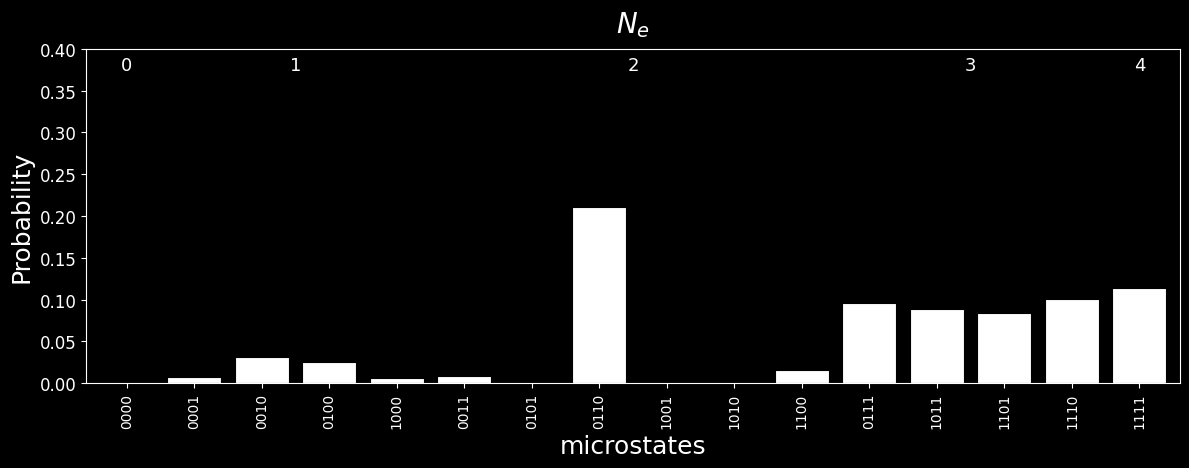

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from itertools import product

# ============================================================
# USTAWIENIA
# ============================================================

CSV_PATH = "experiment_data_fig2d.csv"

# zgodnie z opisem Fig. 2d:
# n_j = 1 oznacza Rydberg excitation
EXCITED_VALUE_IN_CSV = 1

# opcjonalna permutacja kolejności 4 bitów
# None -> bez zmiany
# np. [1, 0, 3, 2] oznacza nową kolejność wierszy: 2,1,4,3
ROW_PERM = None

# zbiory MIS z podpisu do Fig. 2d
MIS_VERTEX_SETS = [{2, 4}, {1, 4}, {1, 3}]

# etykiety wierzchołków odpowiadające kolejności bitów po ewentualnej permutacji
if ROW_PERM is None:
    PLOT_VERTEX_LABELS = [1, 2, 3, 4]
else:
    original_labels = [1, 2, 3, 4]
    PLOT_VERTEX_LABELS = [original_labels[i] for i in ROW_PERM]

# ============================================================
# WCZYTANIE DANYCH
# ============================================================

arr = np.loadtxt(CSV_PATH, delimiter=",").astype(int)

if arr.shape[0] != 4:
    raise ValueError(f"Oczekiwano pliku 4 x M, a jest {arr.shape}")

if ROW_PERM is not None:
    arr = arr[ROW_PERM, :]

# shots x atoms
# 1 = wzbudzenie Rydberga
X = (arr == EXCITED_VALUE_IN_CSV).astype(int).T

n_shots, d = X.shape

# ============================================================
# ZLICZANIE WSZYSTKICH 16 STANÓW
# ============================================================

all_states = list(product([0, 1], repeat=d))
counter = Counter(map(tuple, X))

df = pd.DataFrame({
    "state_tuple": all_states,
    "state": ["".join(map(str, s)) for s in all_states],
    "count": [counter.get(s, 0) for s in all_states],
})

df["probability"] = df["count"] / n_shots
df["Ne"] = [sum(s) for s in df["state_tuple"]]

# sortowanie jak w opisie:
# najpierw według Ne, potem leksykograficznie po bitstringu
df = df.sort_values(["Ne", "state"]).reset_index(drop=True)

# ============================================================
# OZNACZENIE STANÓW MIS
# ============================================================

def vertex_set_to_bitstring(vertex_set, plot_vertex_labels):
    return "".join("1" if v in vertex_set else "0" for v in plot_vertex_labels)

mis_bitstrings = {
    vertex_set_to_bitstring(vs, PLOT_VERTEX_LABELS)
    for vs in MIS_VERTEX_SETS
}

df["is_mis"] = df["state"].isin(mis_bitstrings)

# ============================================================
# TABELKA POMOCNICZA
# ============================================================

print("Kolejność bitów na wykresie odpowiada wierzchołkom:")
print(PLOT_VERTEX_LABELS)
print()

print("Stany MIS zaznaczone na czarno:")
print(sorted(mis_bitstrings))
print()

print(df[["state", "Ne", "count", "probability", "is_mis"]].to_string(index=False))

# ============================================================
# RYSOWANIE WYKRESU
# ============================================================

x = np.arange(len(df))
y = df["probability"].to_numpy()
is_mis = df["is_mis"].to_numpy()

fig, ax = plt.subplots(figsize=(12, 4.8))

# wszystkie słupki - białe
ax.bar(
    x,
    y,
    width=0.8,
    edgecolor="black",
    linewidth=0.8,
    facecolor="white"
)

# słupki MIS - czarne
ax.bar(
    x[is_mis],
    y[is_mis],
    width=0.8,
    edgecolor="black",
    linewidth=0.8,
    facecolor="black"
)

# pionowe linie oddzielające grupy Ne
group_sizes = df.groupby("Ne").size().sort_index().to_numpy()
cum = np.cumsum(group_sizes)

for v in cum[:-1]:
    ax.axvline(v - 0.5, color="black", linewidth=0.8)

# podpisy grup Ne
starts = np.r_[0, cum[:-1]]
ends = cum - 1

ymax = max(0.40, y.max() * 1.25)
ax.set_ylim(0, ymax)

for ne, (a, b) in enumerate(zip(starts, ends)):
    mid = (a + b) / 2
    ax.text(mid, ymax * 0.98, str(ne), ha="center", va="top", fontsize=13)

ax.text((len(df) - 1) / 2, ymax * 1.03, r"$N_e$", ha="center", va="bottom", fontsize=20)

# osie i styl
ax.set_ylabel("Probability", fontsize=18)
ax.set_xlabel("microstates", fontsize=18)

ax.set_xticks(x)
ax.set_xticklabels(df["state"], rotation=90, fontsize=10)

ax.tick_params(axis="y", labelsize=12)
ax.set_xlim(-0.6, len(df) - 0.4)

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import pandas as pd
from collections import Counter
from scipy.optimize import minimize
from scipy.special import logsumexp

# ============================================================
# USTAWIENIA
# ============================================================

CSV_PATH = "experiment_data_fig2k.csv"
EXCITED_VALUE = 1          # 0 = interesujący nas stan
N_BOOT = 300
RANDOM_SEED = 123

# graf z obrazka, ale w indeksacji pythonowej 0,1,2,3
EDGES = [(0, 1), (0, 2), (1, 2), (2, 3)]

# ============================================================
# FUNKCJE POMOCNICZE
# ============================================================

def state_to_string(state):
    return "".join(map(str, state))

def active_vertices_from_state(state):
    return tuple(i + 1 for i, x in enumerate(state) if x == 1)

def is_independent_set(state, edges):
    for u, v in edges:
        if state[u] == 1 and state[v] == 1:
            return False
    return True

def enumerate_independent_sets(d, edges):
    states = []
    for mask in range(1 << d):
        bits = tuple((mask >> i) & 1 for i in range(d))
        if is_independent_set(bits, edges):
            states.append(bits)
    return states

def count_states(X):
    return Counter(map(tuple, X.astype(int)))

def observed_counts_in_state_order(X, states):
    counter = count_states(X)
    return np.array([counter.get(tuple(s), 0) for s in states], dtype=int)

# ============================================================
# MLE dla mult_G(1, y)
# ============================================================

def fit_multG1_mle(X, states, eta_start=None):
    X = np.asarray(X, dtype=int)
    M, d = X.shape
    S = np.asarray(states, dtype=float)
    T = X.sum(axis=0).astype(float)

    if eta_start is None:
        eta_start = np.zeros(d, dtype=float)

    def obj(eta):
        a = S @ eta
        return M * logsumexp(a) - T @ eta

    def grad(eta):
        a = S @ eta
        p = np.exp(a - logsumexp(a))
        mean_state = p @ S
        return M * mean_state - T

    res = minimize(
        fun=obj,
        x0=eta_start,
        jac=grad,
        method="L-BFGS-B"
    )

    if not res.success:
        raise RuntimeError(f"MLE nie zbiega: {res.message}")

    eta_hat = res.x
    logw = S @ eta_hat
    logZ = logsumexp(logw)
    p_hat = np.exp(logw - logZ)
    y_hat = np.exp(eta_hat)

    return {
        "eta_hat": eta_hat,
        "y_hat": y_hat,
        "p_hat": p_hat,
        "logZ": logZ,
        "opt_result": res
    }

# ============================================================
# TEST DOPASOWANIA
# ============================================================

def g_statistic(observed, expected):
    observed = np.asarray(observed, dtype=float)
    expected = np.asarray(expected, dtype=float)
    mask = observed > 0
    return 2.0 * np.sum(observed[mask] * np.log(observed[mask] / expected[mask]))

def parametric_bootstrap_gof(X, states, p_hat, eta_hat, n_boot=300, seed=123):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=int)
    M = X.shape[0]
    S = np.asarray(states, dtype=int)

    obs_counts = observed_counts_in_state_order(X, states)
    exp_counts = M * p_hat
    G_obs = g_statistic(obs_counts, exp_counts)

    boot_stats = []

    for _ in range(n_boot):
        idx = rng.choice(len(states), size=M, replace=True, p=p_hat)
        Xb = S[idx, :]

        fit_b = fit_multG1_mle(Xb, states, eta_start=eta_hat)
        p_b = fit_b["p_hat"]

        obs_b = observed_counts_in_state_order(Xb, states)
        exp_b = M * p_b
        G_b = g_statistic(obs_b, exp_b)
        boot_stats.append(G_b)

    boot_stats = np.asarray(boot_stats, dtype=float)
    p_value = (1 + np.sum(boot_stats >= G_obs)) / (n_boot + 1)

    return {
        "G_obs": G_obs,
        "boot_stats": boot_stats,
        "p_value": p_value
    }

# ============================================================
# WCZYTANIE DANYCH
# ============================================================

arr = np.loadtxt(CSV_PATH, delimiter=",").astype(int)

if arr.shape[0] != 4:
    raise ValueError(f"Ten kod jest ustawiony pod 4 wierzchołki, a plik ma shape {arr.shape}.")

# atoms x shots -> shots x atoms
X_raw = (arr == EXCITED_VALUE).astype(int).T

M_total, d = X_raw.shape
states = enumerate_independent_sets(d, EDGES)
state_strings = [state_to_string(s) for s in states]

# ============================================================
# NOŚNIK MODELU
# ============================================================

valid_state_set = set(states)
mask_valid = np.array([tuple(row) in valid_state_set for row in X_raw], dtype=bool)

n_valid = int(mask_valid.sum())
n_invalid = int((~mask_valid).sum())

print("=== PODSTAWOWE INFO ===")
print(f"Oryginalny shape pliku: {arr.shape}")
print(f"Shape po transpozycji i binarizacji: {X_raw.shape}")
print(f"Interpretacja: EXCITED_VALUE = {EXCITED_VALUE}")
print(f"Krawędzie grafu: {[(u+1, v+1) for u, v in EDGES]}")
print()

print("=== NOŚNIK GRAFU ===")
print(f"Liczba wszystkich strzałów: {M_total}")
print(f"Liczba poprawnych strzałów: {n_valid}")
print(f"Liczba niepoprawnych strzałów: {n_invalid}")
print(f"Odsetek niepoprawnych: {n_invalid / M_total:.6f}")
print()

invalid_counter = Counter(map(tuple, X_raw[~mask_valid]))
if n_invalid > 0:
    print("Najczęstsze stany spoza nośnika:")
    for state, cnt in invalid_counter.most_common():
        print(f"  {state_to_string(state)} : {cnt}")
    print()

# ============================================================
# TABELA SUROWYCH STANÓW
# ============================================================

raw_counter = Counter(map(tuple, X_raw))
raw_df = pd.DataFrame({
    "state": [state_to_string(s) for s in raw_counter.keys()],
    "active_vertices": [str(active_vertices_from_state(s)) for s in raw_counter.keys()],
    "count": list(raw_counter.values())
}).sort_values("count", ascending=False).reset_index(drop=True)

print("=== CZĘSTOŚCI STANÓW W SUROWYCH DANYCH ===")
print(raw_df.to_string(index=False))
print()

# ============================================================
# DOPASOWANIE mult_G(1,y) TYLKO DO POPRAWNYCH STRZAŁÓW
# ============================================================

if n_valid == 0:
    raise RuntimeError("Brak poprawnych strzałów w nośniku grafu.")

X = X_raw[mask_valid].copy()

fit = fit_multG1_mle(X, states)
eta_hat = fit["eta_hat"]
y_hat = fit["y_hat"]
p_hat = fit["p_hat"]

obs_counts = observed_counts_in_state_order(X, states)
exp_counts = len(X) * p_hat

state_df = pd.DataFrame({
    "state": state_strings,
    "active_vertices": [str(active_vertices_from_state(s)) for s in states],
    "observed_count": obs_counts,
    "observed_prob": obs_counts / len(X),
    "expected_prob_hat": p_hat,
    "expected_count_hat": exp_counts,
    "num_excited": [sum(s) for s in states]
}).sort_values(["observed_count", "state"], ascending=[False, True]).reset_index(drop=True)

print("=== ESTYMACJA mult_G(1,y) NA POPRAWNYCH STRZAŁACH ===")
for i, val in enumerate(y_hat, start=1):
    print(f"y_{i} = {val:.6f}")
print()

print("=== TABELA STANÓW W NOŚNIKU ===")
print(state_df.to_string(index=False))
print()

# ============================================================
# TEST DOPASOWANIA
# ============================================================

boot = parametric_bootstrap_gof(
    X=X,
    states=states,
    p_hat=p_hat,
    eta_hat=eta_hat,
    n_boot=N_BOOT,
    seed=RANDOM_SEED
)

print("=== TEST DOPASOWANIA (bootstrap parametryczny) ===")
print(f"G_obs = {boot['G_obs']:.6f}")
print(f"p-value = {boot['p_value']:.6f}")
print()

print("=== INTERPRETACJA ===")
if n_invalid > 0:
    print("Exact mult_G(1,y) dla całych danych odpada, bo są strzały spoza nośnika.")
    print("Test powyżej dotyczy tylko strzałów poprawnych.")
else:
    if boot["p_value"] < 0.05:
        print("Odrzucamy dopasowanie mult_G(1,y).")
    else:
        print("Brak podstaw do odrzucenia mult_G(1,y).")

# zapis
state_df.to_csv("state_table_custom_graph.csv", index=False)
print("\nZapisano tabelę do: state_table_custom_graph.csv")

=== PODSTAWOWE INFO ===
Oryginalny shape pliku: (4, 525)
Shape po transpozycji i binarizacji: (525, 4)
Interpretacja: EXCITED_VALUE = 1
Krawędzie grafu: [(1, 2), (1, 3), (2, 3), (3, 4)]

=== NOŚNIK GRAFU ===
Liczba wszystkich strzałów: 525
Liczba poprawnych strzałów: 73
Liczba niepoprawnych strzałów: 452
Odsetek niepoprawnych: 0.860952

Najczęstsze stany spoza nośnika:
  1010 : 136
  0110 : 83
  1110 : 81
  1111 : 36
  1101 : 35
  1011 : 29
  0111 : 26
  0011 : 13
  1100 : 13

=== CZĘSTOŚCI STANÓW W SUROWYCH DANYCH ===
state active_vertices  count
 1010          (1, 3)    136
 0110          (2, 3)     83
 1110       (1, 2, 3)     81
 0010            (3,)     39
 1111    (1, 2, 3, 4)     36
 1101       (1, 2, 4)     35
 1011       (1, 3, 4)     29
 0111       (2, 3, 4)     26
 1100          (1, 2)     13
 0011          (3, 4)     13
 0101          (2, 4)     10
 1000            (1,)      9
 1001          (1, 4)      9
 0100            (2,)      4
 0001            (4,)      1
 0000      

In [19]:
import numpy as np
import pandas as pd
from collections import Counter
from scipy.optimize import minimize
from scipy.special import logsumexp

# ============================================================
# USTAWIENIA
# ============================================================

CSV_PATH = "experiment_data_fig2j.csv"
EXCITED_VALUE = 1          # 0 = interesujący nas stan
N_BOOT = 300
RANDOM_SEED = 123

# graf z obrazka, ale w indeksacji pythonowej 0,1,2,3
EDGES = [ (0, 2), (1, 2), (2, 3)]

# ============================================================
# FUNKCJE POMOCNICZE
# ============================================================

def state_to_string(state):
    return "".join(map(str, state))

def active_vertices_from_state(state):
    return tuple(i + 1 for i, x in enumerate(state) if x == 1)

def is_independent_set(state, edges):
    for u, v in edges:
        if state[u] == 1 and state[v] == 1:
            return False
    return True

def enumerate_independent_sets(d, edges):
    states = []
    for mask in range(1 << d):
        bits = tuple((mask >> i) & 1 for i in range(d))
        if is_independent_set(bits, edges):
            states.append(bits)
    return states

def count_states(X):
    return Counter(map(tuple, X.astype(int)))

def observed_counts_in_state_order(X, states):
    counter = count_states(X)
    return np.array([counter.get(tuple(s), 0) for s in states], dtype=int)

# ============================================================
# MLE dla mult_G(1, y)
# ============================================================

def fit_multG1_mle(X, states, eta_start=None):
    X = np.asarray(X, dtype=int)
    M, d = X.shape
    S = np.asarray(states, dtype=float)
    T = X.sum(axis=0).astype(float)

    if eta_start is None:
        eta_start = np.zeros(d, dtype=float)

    def obj(eta):
        a = S @ eta
        return M * logsumexp(a) - T @ eta

    def grad(eta):
        a = S @ eta
        p = np.exp(a - logsumexp(a))
        mean_state = p @ S
        return M * mean_state - T

    res = minimize(
        fun=obj,
        x0=eta_start,
        jac=grad,
        method="L-BFGS-B"
    )

    if not res.success:
        raise RuntimeError(f"MLE nie zbiega: {res.message}")

    eta_hat = res.x
    logw = S @ eta_hat
    logZ = logsumexp(logw)
    p_hat = np.exp(logw - logZ)
    y_hat = np.exp(eta_hat)

    return {
        "eta_hat": eta_hat,
        "y_hat": y_hat,
        "p_hat": p_hat,
        "logZ": logZ,
        "opt_result": res
    }

# ============================================================
# TEST DOPASOWANIA
# ============================================================

def g_statistic(observed, expected):
    observed = np.asarray(observed, dtype=float)
    expected = np.asarray(expected, dtype=float)
    mask = observed > 0
    return 2.0 * np.sum(observed[mask] * np.log(observed[mask] / expected[mask]))

def parametric_bootstrap_gof(X, states, p_hat, eta_hat, n_boot=300, seed=123):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=int)
    M = X.shape[0]
    S = np.asarray(states, dtype=int)

    obs_counts = observed_counts_in_state_order(X, states)
    exp_counts = M * p_hat
    G_obs = g_statistic(obs_counts, exp_counts)

    boot_stats = []

    for _ in range(n_boot):
        idx = rng.choice(len(states), size=M, replace=True, p=p_hat)
        Xb = S[idx, :]

        fit_b = fit_multG1_mle(Xb, states, eta_start=eta_hat)
        p_b = fit_b["p_hat"]

        obs_b = observed_counts_in_state_order(Xb, states)
        exp_b = M * p_b
        G_b = g_statistic(obs_b, exp_b)
        boot_stats.append(G_b)

    boot_stats = np.asarray(boot_stats, dtype=float)
    p_value = (1 + np.sum(boot_stats >= G_obs)) / (n_boot + 1)

    return {
        "G_obs": G_obs,
        "boot_stats": boot_stats,
        "p_value": p_value
    }

# ============================================================
# WCZYTANIE DANYCH
# ============================================================

arr = np.loadtxt(CSV_PATH, delimiter=",").astype(int)

if arr.shape[0] != 4:
    raise ValueError(f"Ten kod jest ustawiony pod 4 wierzchołki, a plik ma shape {arr.shape}.")

# atoms x shots -> shots x atoms
X_raw = (arr == EXCITED_VALUE).astype(int).T

M_total, d = X_raw.shape
states = enumerate_independent_sets(d, EDGES)
state_strings = [state_to_string(s) for s in states]

# ============================================================
# NOŚNIK MODELU
# ============================================================

valid_state_set = set(states)
mask_valid = np.array([tuple(row) in valid_state_set for row in X_raw], dtype=bool)

n_valid = int(mask_valid.sum())
n_invalid = int((~mask_valid).sum())

print("=== PODSTAWOWE INFO ===")
print(f"Oryginalny shape pliku: {arr.shape}")
print(f"Shape po transpozycji i binarizacji: {X_raw.shape}")
print(f"Interpretacja: EXCITED_VALUE = {EXCITED_VALUE}")
print(f"Krawędzie grafu: {[(u+1, v+1) for u, v in EDGES]}")
print()

print("=== NOŚNIK GRAFU ===")
print(f"Liczba wszystkich strzałów: {M_total}")
print(f"Liczba poprawnych strzałów: {n_valid}")
print(f"Liczba niepoprawnych strzałów: {n_invalid}")
print(f"Odsetek niepoprawnych: {n_invalid / M_total:.6f}")
print()

invalid_counter = Counter(map(tuple, X_raw[~mask_valid]))
if n_invalid > 0:
    print("Najczęstsze stany spoza nośnika:")
    for state, cnt in invalid_counter.most_common():
        print(f"  {state_to_string(state)} : {cnt}")
    print()

# ============================================================
# TABELA SUROWYCH STANÓW
# ============================================================

raw_counter = Counter(map(tuple, X_raw))
raw_df = pd.DataFrame({
    "state": [state_to_string(s) for s in raw_counter.keys()],
    "active_vertices": [str(active_vertices_from_state(s)) for s in raw_counter.keys()],
    "count": list(raw_counter.values())
}).sort_values("count", ascending=False).reset_index(drop=True)

print("=== CZĘSTOŚCI STANÓW W SUROWYCH DANYCH ===")
print(raw_df.to_string(index=False))
print()

# ============================================================
# DOPASOWANIE mult_G(1,y) TYLKO DO POPRAWNYCH STRZAŁÓW
# ============================================================

if n_valid == 0:
    raise RuntimeError("Brak poprawnych strzałów w nośniku grafu.")

X = X_raw[mask_valid].copy()

fit = fit_multG1_mle(X, states)
eta_hat = fit["eta_hat"]
y_hat = fit["y_hat"]
p_hat = fit["p_hat"]

obs_counts = observed_counts_in_state_order(X, states)
exp_counts = len(X) * p_hat

state_df = pd.DataFrame({
    "state": state_strings,
    "active_vertices": [str(active_vertices_from_state(s)) for s in states],
    "observed_count": obs_counts,
    "observed_prob": obs_counts / len(X),
    "expected_prob_hat": p_hat,
    "expected_count_hat": exp_counts,
    "num_excited": [sum(s) for s in states]
}).sort_values(["observed_count", "state"], ascending=[False, True]).reset_index(drop=True)

print("=== ESTYMACJA mult_G(1,y) NA POPRAWNYCH STRZAŁACH ===")
for i, val in enumerate(y_hat, start=1):
    print(f"y_{i} = {val:.6f}")
print()

print("=== TABELA STANÓW W NOŚNIKU ===")
print(state_df.to_string(index=False))
print()

# ============================================================
# TEST DOPASOWANIA
# ============================================================

boot = parametric_bootstrap_gof(
    X=X,
    states=states,
    p_hat=p_hat,
    eta_hat=eta_hat,
    n_boot=N_BOOT,
    seed=RANDOM_SEED
)

print("=== TEST DOPASOWANIA (bootstrap parametryczny) ===")
print(f"G_obs = {boot['G_obs']:.6f}")
print(f"p-value = {boot['p_value']:.6f}")
print()

print("=== INTERPRETACJA ===")
if n_invalid > 0:
    print("Exact mult_G(1,y) dla całych danych odpada, bo są strzały spoza nośnika.")
    print("Test powyżej dotyczy tylko strzałów poprawnych.")
else:
    if boot["p_value"] < 0.05:
        print("Odrzucamy dopasowanie mult_G(1,y).")
    else:
        print("Brak podstaw do odrzucenia mult_G(1,y).")

# zapis
state_df.to_csv("state_table_custom_graph.csv", index=False)
print("\nZapisano tabelę do: state_table_custom_graph.csv")

=== PODSTAWOWE INFO ===
Oryginalny shape pliku: (4, 425)
Shape po transpozycji i binarizacji: (425, 4)
Interpretacja: EXCITED_VALUE = 1
Krawędzie grafu: [(1, 3), (2, 3), (3, 4)]

=== NOŚNIK GRAFU ===
Liczba wszystkich strzałów: 425
Liczba poprawnych strzałów: 183
Liczba niepoprawnych strzałów: 242
Odsetek niepoprawnych: 0.569412

Najczęstsze stany spoza nośnika:
  1010 : 66
  0011 : 52
  0110 : 48
  1110 : 24
  1011 : 21
  0111 : 16
  1111 : 15

=== CZĘSTOŚCI STANÓW W SUROWYCH DANYCH ===
state active_vertices  count
 0010            (3,)    125
 1010          (1, 3)     66
 0011          (3, 4)     52
 0110          (2, 3)     48
 1110       (1, 2, 3)     24
 1011       (1, 3, 4)     21
 1101       (1, 2, 4)     21
 0111       (2, 3, 4)     16
 1111    (1, 2, 3, 4)     15
 0101          (2, 4)     13
 1100          (1, 2)      7
 1000            (1,)      6
 0100            (2,)      4
 1001          (1, 4)      3
 0000              ()      3
 0001            (4,)      1

=== ESTYMACJA

In [22]:
import numpy as np
import pandas as pd
from collections import Counter
from scipy.optimize import minimize
from scipy.special import logsumexp

# ============================================================
# USTAWIENIA
# ============================================================

CSV_PATH = "experiment_data_fig4d.csv"
EXCITED_VALUE = 1          # 1 = interesujący nas stan
N_BOOT = 300
RANDOM_SEED = 123

# graf z obrazka, ale w indeksacji pythonowej 0..12
# czyli:
# 1->0, 2->1, ..., 13->12
EDGES = [
    (7, 2),   # 8-3
    (7, 1),   # 8-2
    (7, 8),   # 8-9
    (8, 0),   # 9-1

    (0, 10),  # 1-11
    (10, 9),  # 11-10
    (9, 3),   # 10-4
    (9, 4),   # 10-5

    (0, 12),  # 1-13
    (12, 11), # 13-12
    (11, 6),  # 12-7
    (11, 5),  # 12-6
]

# ============================================================
# FUNKCJE POMOCNICZE
# ============================================================

def state_to_string(state):
    return "".join(map(str, state))

def active_vertices_from_state(state):
    return tuple(i + 1 for i, x in enumerate(state) if x == 1)

def is_independent_set(state, edges):
    for u, v in edges:
        if state[u] == 1 and state[v] == 1:
            return False
    return True

def enumerate_independent_sets(d, edges):
    states = []
    for mask in range(1 << d):
        bits = tuple((mask >> i) & 1 for i in range(d))
        if is_independent_set(bits, edges):
            states.append(bits)
    return states

def count_states(X):
    return Counter(map(tuple, X.astype(int)))

def observed_counts_in_state_order(X, states):
    counter = count_states(X)
    return np.array([counter.get(tuple(s), 0) for s in states], dtype=int)

# ============================================================
# MLE dla mult_G(1, y)
# ============================================================

def fit_multG1_mle(X, states, eta_start=None):
    X = np.asarray(X, dtype=int)
    M, d = X.shape
    S = np.asarray(states, dtype=float)
    T = X.sum(axis=0).astype(float)

    if eta_start is None:
        eta_start = np.zeros(d, dtype=float)

    def obj(eta):
        a = S @ eta
        return M * logsumexp(a) - T @ eta

    def grad(eta):
        a = S @ eta
        p = np.exp(a - logsumexp(a))
        mean_state = p @ S
        return M * mean_state - T

    res = minimize(
        fun=obj,
        x0=eta_start,
        jac=grad,
        method="L-BFGS-B"
    )

    if not res.success:
        raise RuntimeError(f"MLE nie zbiega: {res.message}")

    eta_hat = res.x
    logw = S @ eta_hat
    logZ = logsumexp(logw)
    p_hat = np.exp(logw - logZ)
    y_hat = np.exp(eta_hat)

    return {
        "eta_hat": eta_hat,
        "y_hat": y_hat,
        "p_hat": p_hat,
        "logZ": logZ,
        "opt_result": res
    }

# ============================================================
# TEST DOPASOWANIA
# ============================================================

def g_statistic(observed, expected):
    observed = np.asarray(observed, dtype=float)
    expected = np.asarray(expected, dtype=float)
    mask = observed > 0
    return 2.0 * np.sum(observed[mask] * np.log(observed[mask] / expected[mask]))

def parametric_bootstrap_gof(X, states, p_hat, eta_hat, n_boot=300, seed=123):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=int)
    M = X.shape[0]
    S = np.asarray(states, dtype=int)

    obs_counts = observed_counts_in_state_order(X, states)
    exp_counts = M * p_hat
    G_obs = g_statistic(obs_counts, exp_counts)

    boot_stats = []

    for _ in range(n_boot):
        idx = rng.choice(len(states), size=M, replace=True, p=p_hat)
        Xb = S[idx, :]

        fit_b = fit_multG1_mle(Xb, states, eta_start=eta_hat)
        p_b = fit_b["p_hat"]

        obs_b = observed_counts_in_state_order(Xb, states)
        exp_b = M * p_b
        G_b = g_statistic(obs_b, exp_b)
        boot_stats.append(G_b)

    boot_stats = np.asarray(boot_stats, dtype=float)
    p_value = (1 + np.sum(boot_stats >= G_obs)) / (n_boot + 1)

    return {
        "G_obs": G_obs,
        "boot_stats": boot_stats,
        "p_value": p_value
    }

# ============================================================
# WCZYTANIE DANYCH
# ============================================================

arr = np.loadtxt(CSV_PATH, delimiter=",").astype(int)

if arr.shape[0] != 13:
    raise ValueError(f"Ten kod jest ustawiony pod 13 wierzchołków, a plik ma shape {arr.shape}.")

# atoms x shots -> shots x atoms
X_raw = (arr == EXCITED_VALUE).astype(int).T

M_total, d = X_raw.shape
states = enumerate_independent_sets(d, EDGES)
state_strings = [state_to_string(s) for s in states]

# ============================================================
# NOŚNIK MODELU
# ============================================================

valid_state_set = set(states)
mask_valid = np.array([tuple(row) in valid_state_set for row in X_raw], dtype=bool)

n_valid = int(mask_valid.sum())
n_invalid = int((~mask_valid).sum())

print("=== PODSTAWOWE INFO ===")
print(f"Oryginalny shape pliku: {arr.shape}")
print(f"Shape po transpozycji i binarizacji: {X_raw.shape}")
print(f"Interpretacja: EXCITED_VALUE = {EXCITED_VALUE}")
print(f"Krawędzie grafu: {[(u+1, v+1) for u, v in EDGES]}")
print(f"Liczba stanów w nośniku: {len(states)}")
print()

print("=== NOŚNIK GRAFU ===")
print(f"Liczba wszystkich strzałów: {M_total}")
print(f"Liczba poprawnych strzałów: {n_valid}")
print(f"Liczba niepoprawnych strzałów: {n_invalid}")
print(f"Odsetek niepoprawnych: {n_invalid / M_total:.6f}")
print()

invalid_counter = Counter(map(tuple, X_raw[~mask_valid]))
if n_invalid > 0:
    print("Najczęstsze stany spoza nośnika:")
    for state, cnt in invalid_counter.most_common(20):
        print(f"  {state_to_string(state)} : {cnt}")
    print()

# ============================================================
# TABELA SUROWYCH STANÓW
# ============================================================

raw_counter = Counter(map(tuple, X_raw))
raw_df = pd.DataFrame({
    "state": [state_to_string(s) for s in raw_counter.keys()],
    "active_vertices": [str(active_vertices_from_state(s)) for s in raw_counter.keys()],
    "count": list(raw_counter.values())
}).sort_values("count", ascending=False).reset_index(drop=True)

print("=== CZĘSTOŚCI STANÓW W SUROWYCH DANYCH ===")
print(raw_df.to_string(index=False))
print()

# ============================================================
# DOPASOWANIE mult_G(1,y) TYLKO DO POPRAWNYCH STRZAŁÓW
# ============================================================

if n_valid == 0:
    raise RuntimeError("Brak poprawnych strzałów w nośniku grafu.")

X = X_raw[mask_valid].copy()

fit = fit_multG1_mle(X, states)
eta_hat = fit["eta_hat"]
y_hat = fit["y_hat"]
p_hat = fit["p_hat"]

obs_counts = observed_counts_in_state_order(X, states)
exp_counts = len(X) * p_hat

state_df = pd.DataFrame({
    "state": state_strings,
    "active_vertices": [str(active_vertices_from_state(s)) for s in states],
    "observed_count": obs_counts,
    "observed_prob": obs_counts / len(X),
    "expected_prob_hat": p_hat,
    "expected_count_hat": exp_counts,
    "num_excited": [sum(s) for s in states]
}).sort_values(["observed_count", "state"], ascending=[False, True]).reset_index(drop=True)

print("=== ESTYMACJA mult_G(1,y) NA POPRAWNYCH STRZAŁACH ===")
for i, val in enumerate(y_hat, start=1):
    print(f"y_{i} = {val:.6f}")
print()

print("=== TABELA STANÓW W NOŚNIKU ===")
print(state_df.to_string(index=False))
print()

# ============================================================
# TEST DOPASOWANIA
# ============================================================

boot = parametric_bootstrap_gof(
    X=X,
    states=states,
    p_hat=p_hat,
    eta_hat=eta_hat,
    n_boot=N_BOOT,
    seed=RANDOM_SEED
)

print("=== TEST DOPASOWANIA (bootstrap parametryczny) ===")
print(f"G_obs = {boot['G_obs']:.6f}")
print(f"p-value = {boot['p_value']:.6f}")
print()

print("=== INTERPRETACJA ===")
if n_invalid > 0:
    print("Exact mult_G(1,y) dla całych danych odpada, bo są strzały spoza nośnika.")
    print("Test powyżej dotyczy tylko strzałów poprawnych.")
else:
    if boot["p_value"] < 0.05:
        print("Odrzucamy dopasowanie mult_G(1,y).")
    else:
        print("Brak podstaw do odrzucenia mult_G(1,y).")

# zapis
state_df.to_csv("state_table_graph13.csv", index=False)
print("\nZapisano tabelę do: state_table_graph13.csv")


=== PODSTAWOWE INFO ===
Oryginalny shape pliku: (13, 1033)
Shape po transpozycji i binarizacji: (1033, 13)
Interpretacja: EXCITED_VALUE = 1
Krawędzie grafu: [(8, 3), (8, 2), (8, 9), (9, 1), (1, 11), (11, 10), (10, 4), (10, 5), (1, 13), (13, 12), (12, 7), (12, 6)]
Liczba stanów w nośniku: 854

=== NOŚNIK GRAFU ===
Liczba wszystkich strzałów: 1033
Liczba poprawnych strzałów: 6
Liczba niepoprawnych strzałów: 1027
Odsetek niepoprawnych: 0.994192

Najczęstsze stany spoza nośnika:
  1000000111000 : 45
  1000010111000 : 19
  1001000111000 : 15
  1000000111001 : 13
  1000000111100 : 13
  1000000111010 : 11
  1000100111000 : 11
  1000001111000 : 9
  1001100111000 : 9
  1110000111000 : 9
  1100000111000 : 8
  1100000111010 : 8
  1000011111000 : 8
  1000010111010 : 6
  1000000111111 : 6
  1000000111110 : 6
  1000100111100 : 6
  1001000111100 : 6
  1000011110101 : 6
  1100010111000 : 5

=== CZĘSTOŚCI STANÓW W SUROWYCH DANYCH ===
        state                          active_vertices  count
1000000